<a href="https://colab.research.google.com/github/Mariano-ds/centollas2026/blob/main/mariano/mariano_tp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

---
## Mentoría 15: *¿Cuándo y dónde pescar Centollas en el Canal Beagle?*

**Objetivo**: comprender la base de datos para determinar su alcance (y su no-alcance).

**Fecha de entrega:** 31/07

**Integrantes:**

- _BAGGINI, Mariano_
- _RODRIGO_
- _FRANCISCO_

## Consignas

1. **Analizar mediante estadística descriptiva cada variable** del set de datos que se considere pertinente, con el objetivo de entender qué se está estudiando.

2. **Realizar al menos 3 gráficos exploratorios** que respondan a preguntas concretas y sencillas planteadas por el grupo. Se espera que se presenten distintos gráficos y que las visualizaciones tengan fácil interpretación: título del gráfico, tamaño adecuado del nombre de los ejes X e Y (si el gráfico los tuviese), uso adecuado de la paleta de colores.

Cada gráfico debe ser acompañado por un epígrafe que facilite aún mas la comprensión de lo que se está mostrando, así como también un párrafo de interpretación de resultados.

3. **Plantear 5 preguntas que podrían potencialmente ser respondidas con esta base de datos**. Se espera que, para responder cada una de las preguntas, se usen al menos dos variables del set de datos. Algunas preguntas como ejemplo para este análisis:

* ¿hay diferencias en las abundancias entre centollones y centollas? ¿y entre machos y hembras?

* ¿hay diferencias en el tamaño de caparazón en el tiempo considerado? ¿y en las abundancias?

* ¿alguna especie es más susceptible a cirripedios y/o a los parásitos? ¿se observan variaciones temporales en esto?

* ¿Cuándo se encontraron más huevos en las hembras?

Se valorará positivamente la relación/conexión entre las preguntas.

### 0. Carga del dataset

In [3]:
# Librerias utilizadas
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import re

sns.set_context('talk')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [4]:
# Importo dataset
url = "https://raw.github.com/luciabergagna-jpg/centoll/main/centollas_mentoria.csv"
cent_data = pd.read_csv(url, sep=';', engine='python', encoding='latin1')

In [5]:
# Copia de trabajo
cent_raw = cent_data.copy()
cent_raw.head(3)

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,Unnamed: 18,Unnamed: 19
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2,77.1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
2,ene_96,3,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,NaN,74.6,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN


Exploracion inicial de los datos

In [6]:
cent_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11050 entries, 0 to 11049
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             11050 non-null  object 
 1   rk                11050 non-null  int64  
 2   tipo              11050 non-null  object 
 3   localizacion      7669 non-null   object 
 4   latitud           6508 non-null   float64
 5   longitud          6508 non-null   float64
 6   profundidad       8303 non-null   float64
 7   especie           11050 non-null  int64  
 8   sexo              11050 non-null  int64  
 9   estado_caparazon  11043 non-null  float64
 10  cirripedio        1326 non-null   object 
 11  largo_caparazon   11024 non-null  float64
 12  ancho_caparazon   183 non-null    float64
 13  largo_quela       155 non-null    float64
 14  ancho_quela       157 non-null    float64
 15  huevos            3054 non-null   object 
 16  parasito          268 non-null    object

Antes de analizar, conviene documentar **con qué arrancamos**. El archivo crudo
`centollas_mentoria.csv` es una tabla plana donde **cada fila es un individuo**, en formato de
planilla de campo:

- **Separador `;`** y **codificación latin-1** (no UTF-8): con la configuración por defecto la
  lectura fallaba en los acentos y la ñ.
- **20 columnas leídas**: 18 con información + **2 columnas finales sin nombre (`Unnamed: 18`,
  `Unnamed: 19`)**, producto de los `;` sobrantes al final de cada fila.

La siguiente celda muestra, para **cada columna original**, su significado y las unidades o codificación en la que se expresan.

### Informacion acerca de las variables

Datos genrales de las campañas:

- enero_96 > Muestreo a bordo de Wapisa, 26/01/96; WAPJAN96
- abril_96 > Muestreo a bordo de Catamarca 2/4/96
- julio_96 > Muestreo a bordo de Wapisa y Catamarca, 24 y 25.07.96; LANJUL96.WQ1
- octubre_96 > Muestreo a bordo de Catamarca, 2 y 3.10.96; CATOCT96.WQ1
- octubre_97 > Muestreo a bordo de la Catamarca el 6 y 7 de octubre de 1997
- octubre_98 > Muestreo a bordo de la Catamarca el 13 de octubre de 1998

La codificación de las variables categóricas se reconstruyó a partir del protocolo de muestreo
(Lovrich, *Lithodes - Muestreo*) que documenta el criterio de toma de datos en el campo.

| Variable | Descripción | Códigos / Unidades |
|---|---|---|
| `fecha` | Temporada de muestreo | ene_96, abril_96, jul_96, oct_96, oct_97, oct_98 |
| `rk` | Número de registro/individuo dentro de la temporada | entero |
| `tipo` | Tipo de captura y cantidad de trampas (o desembarque) del punto de muestreo | texto, p.ej. "Captura total de 3 trampas" |
| `localizacion` | Punto de referencia geográfico del muestreo | texto libre |
| `latitud`, `longitud` | Coordenadas del punto de muestreo | grados decimales |
| `profundidad` | Profundidad del punto de muestreo | metros |
| `especie` | Especie del individuo | 1 = centollón (*Paralomis granulosa*), 2 = centolla (*Lithodes santolla*)* |
| `sexo` | Sexo del individuo | 1 = macho, 2 = hembra* |
| `estado_caparazon` | Estado del caparazón / epibiosis | 1 postmuda, 2 duro sin epibiontes, 3 duro con epibiontes (Spirorbis), 4 duro con epibiontes (Balanus), 5 duro con 2º caparazón visible, 6 exuvia |
| `cirripedio` | Presencia/nivel de cirripedios (parásito *Briarosaccus*) | 1–3 (nivel), sufijo "p" en algunos registros |
| `largo_caparazon` | Largo del caparazón (LC) | mm |
| `ancho_caparazon` | Ancho del caparazón | mm |
| `largo_quela` | Largo de la pinza derecha | mm |
| `ancho_quela` | Ancho de la pinza derecha | mm |
| `huevos` | Estado de desarrollo de los huevos (solo hembras) | 0 sin huevos, 1 huevos sin ojos, 2 huevos sin ojos con mancha blanca, 3 huevos con ojos, 4 eclosionando, 5 cápsulas vacías (postovígera), 6 embriogénesis heterogénea, 7 trazas |
| `parasito` | Presencia de parásito *Pseudione* | 2 isopodo presente, 20 isopodo cicatriz, 3 rizocefalo presente, 30 rizocefalo cicatriz |
| `observaciones` | Notas de campo | texto libre |

\* La correspondencia numérica de `especie` y `sexo` no está documentada explícitamente en el material de la cátedra. Se infiere por la proporción esperada de capturas en la pesquería de centolla del canal Beagle (la centolla es la especie objetivo y por lo tanto la más abundante en la muestra; los machos son mayoritarios porque las hembras están protegidas/se descartan). **Este supuesto debe validarse con la cátedra antes del TP2.**

In [7]:
cent_raw.sample(3)

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,Unnamed: 18,Unnamed: 19
4852,oct_96,282,Captura total de 10 trampas,wp 58,-54.906617,-67.356100,21.0,2,1,3.0,NaN,70.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8971,oct_98,387,Captura total de 2.5 trampas,wp 239,-54.897000,-67.560417,26.0,2,1,3.0,NaN,88.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9902,oct_98,1318,Captura total de 2.5 trampas,wp 243,-54.903817,-67.216117,33.0,2,1,3.0,NaN,84.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1. Análisis mediante estadística descriptiva

<Axes: >

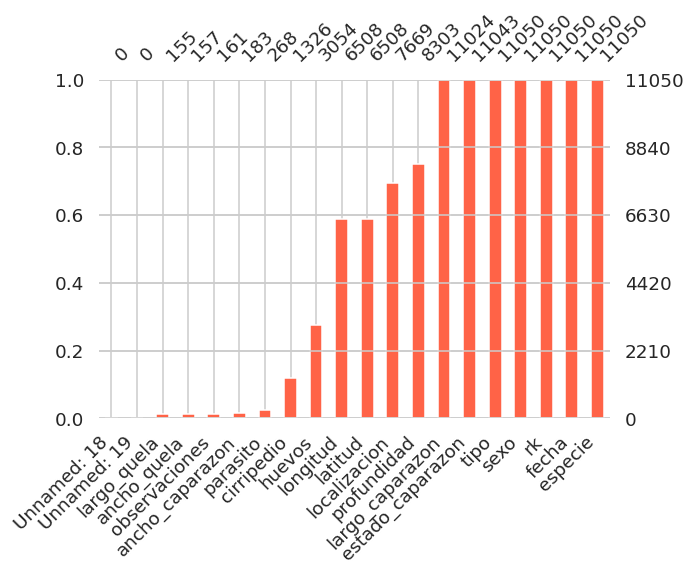

In [8]:
# Visualizacion de valores nulos
msno.bar(cent_raw,figsize=(6, 4), sort="ascending",fontsize=12, color='tomato')

**Epígrafe:** Valores faltantes (NaN) por variable, sobre el total de 11.050 registros.

**Interpretación:** Las variables morfométricas secundarias (ancho_caparazon, largo_quela y ancho_quela), junto a observaciones y parasito, faltan en más del 95% de los casos: probablemente solo se midieron en sub-muestras específicas o campañas puntuales, no de forma sistemática en todas las temporadas. huevos y cirripedio faltan en ~72–88% de los registros, lo cual es esperable porque solo aplican a hembras (huevos) o a una fracción de la muestra revisada para epibiontes. largo_caparazon, en cambio, es la variable morfométrica más completa (falta en <1%), por lo que es la más confiable para comparar tamaños entre especies, sexos y temporadas. Esta estructura de faltantes define el alcance del dataset: es sólido para preguntas sobre tamaño, especie, sexo y ubicación/profundidad, pero limitado para preguntas finas sobre parasitismo o morfometría de la pinza, donde el n útil es mucho menor.

In [9]:
# Estudio porcentual de valores nulos
faltantes = cent_raw.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

Unnamed: 18         100.00
Unnamed: 19         100.00
largo_quela          98.60
ancho_quela          98.58
observaciones        98.54
ancho_caparazon      98.34
parasito             97.57
cirripedio           88.00
huevos               72.36
latitud              41.10
longitud             41.10
localizacion         30.60
profundidad          24.86
largo_caparazon       0.24
estado_caparazon      0.06
dtype: float64


**Interpretación y decisiones de partida.**

- **Por qué se eliminan `Unnamed: 18` y `Unnamed: 19`:** están **100% vacías** (11.050/11.050 nulos,
  0 valores distintos). No aportan datos reales, se descartan para disminuir el ruido en el dataset.
- **Columnas con alto valor y buena completitud:** `fecha`, `tipo`, `especie`, `sexo`,
  `estado_caparazon` y `largo_caparazon` (todas con <1% de faltantes). Son el núcleo del análisis.
- **Columnas de valor potencial pero completitud parcial:** `profundidad` (~25% vacío),
  `latitud`/`longitud` (~41%) y `localizacion` (~31%): permiten un abordaje **aproximado** del "dónde".
- **Columnas prácticamente inservibles:** `ancho_caparazon`, `largo_quela` y `ancho_quela`
  (>98% vacías) → quedan **fuera del alcance**. `observaciones` (98,5%) es texto libre no estructurado.
- **Presencias con muchos ceros/vacíos:** `cirripedio` (88%), `parasito` (97,6%) y `huevos` (72,4%):
  se analizan como **presencia/ausencia**, no como valores continuos.

In [10]:
# Se eliminan columnas vacías generadas por separadores sobrantes al final de cada fila
cent_raw = cent_raw.loc[:, ~cent_raw.columns.str.startswith("Unnamed")]
print(f"Filas: {cent_raw.shape[0]:,} | Columnas: {cent_raw.shape[1]}")

Filas: 11,050 | Columnas: 18


Ahora veamos una descripción de las variables numéricas no-categóricas:

In [11]:
num_var = ['largo_caparazon', 'ancho_caparazon', 'largo_quela', 'ancho_quela',
           'longitud', 'latitud', 'profundidad']
cent_raw[num_var].describe().round(3)

,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,longitud,latitud,profundidad
count,11024.000,183.000,155.000,157.000,6508.000,6508.000,8303.000
mean,79.158,109.728,70.903,32.609,-67.298,-54.908,31.134
std,11.477,24.172,15.548,8.953,0.189,0.013,8.186
min,8.100,56.500,38.400,13.400,-67.791,-54.938,19.000
25%,71.400,91.850,59.600,26.400,-67.358,-54.921,25.000
50%,79.000,105.100,69.400,31.400,-67.225,-54.906,30.000
75%,86.400,124.050,79.500,37.700,-67.146,-54.900,38.000
max,156.200,175.100,119.600,55.400,-67.064,-54.874,49.000


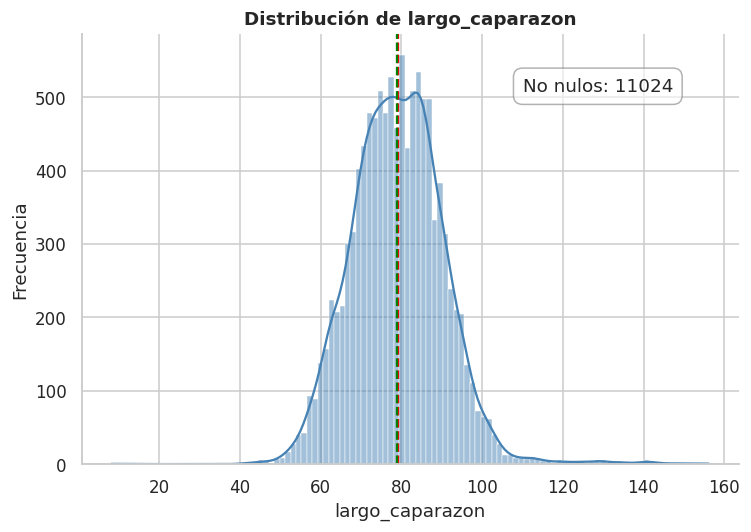

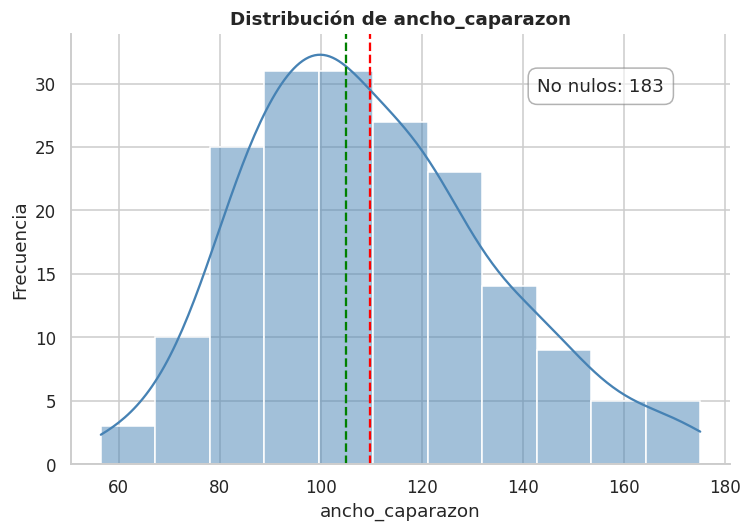

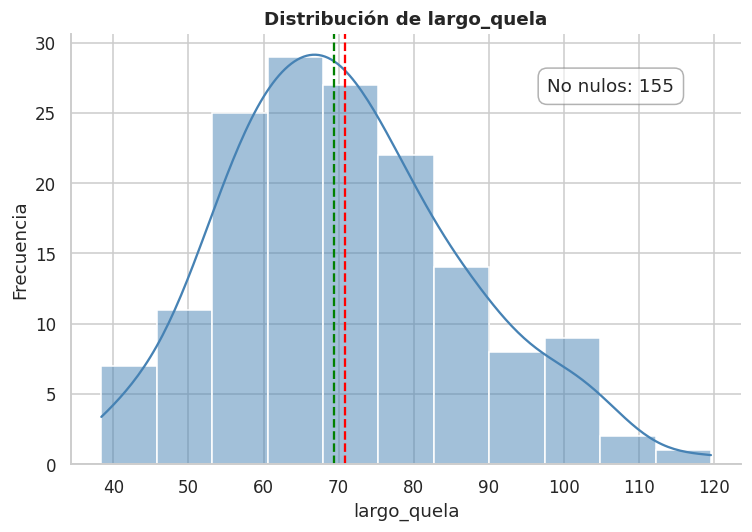

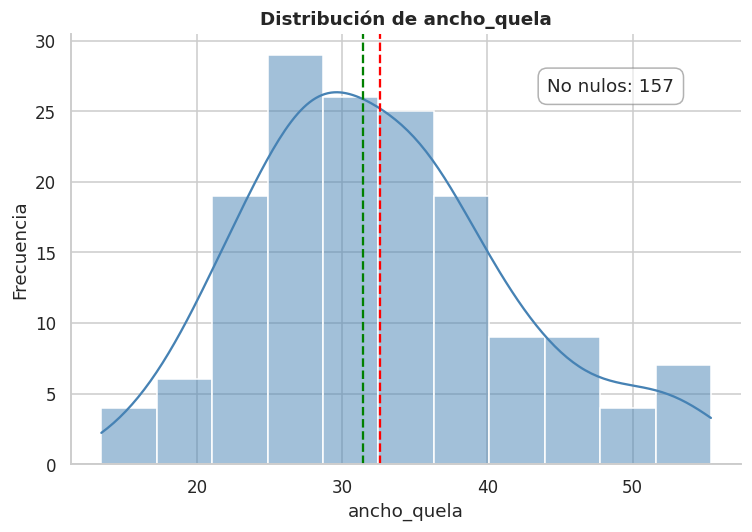

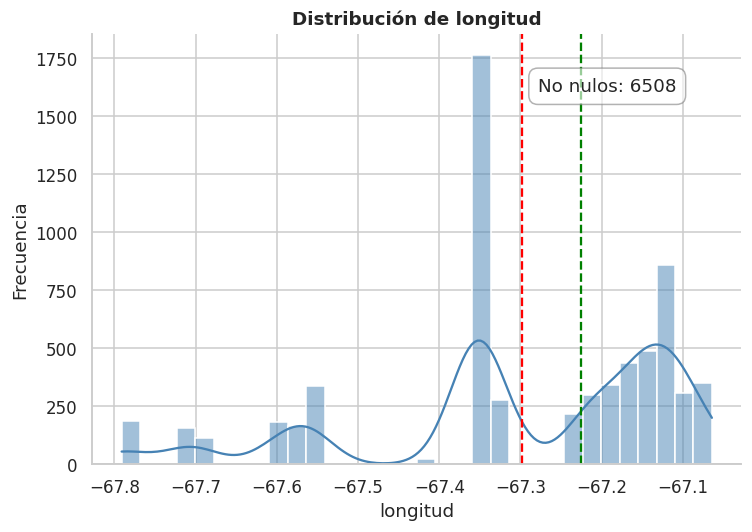

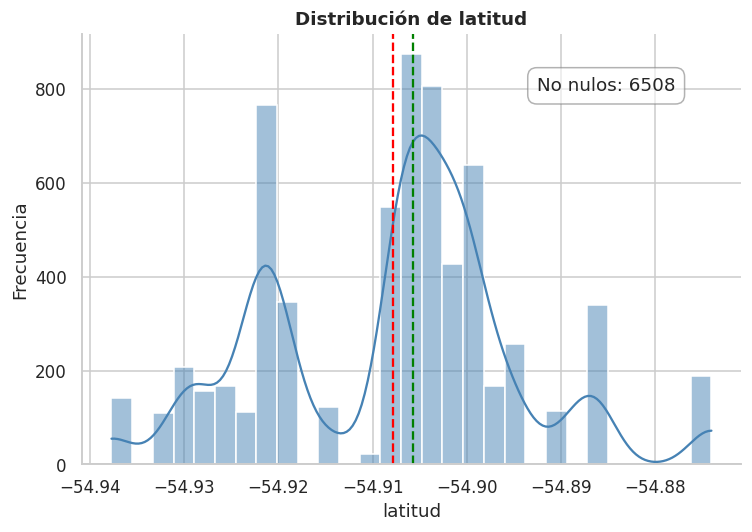

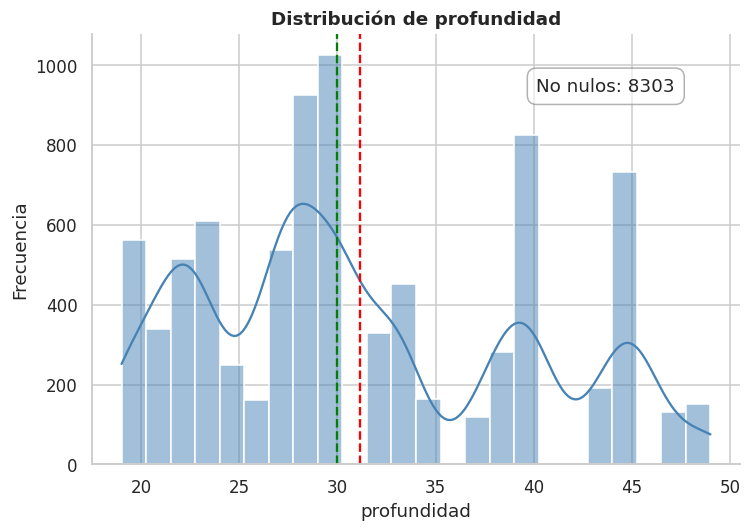

In [12]:
# Bucle para generar un gráfico por cada columna
for col in num_var:
    plt.figure(figsize=(7, 5))

    # 1. Histograma con curva KDE
    ax = sns.histplot(cent_raw[col], kde=True, color='steelblue')

    # 2. Cálculos estadísticos
    no_nulos = cent_raw[col].notna().sum()
    media = cent_raw[col].mean()
    mediana = cent_raw[col].median()

    # 3. Líneas de media (roja) y mediana (verde)
    ax.axvline(
        media,
        color='red',
        linestyle='--',
        linewidth=1.5,
        label=f'Media: {media:.2f}',
    )
    ax.axvline(
        mediana,
        color='green',
        linestyle='--',
        linewidth=1.5,
        label=f'Mediana: {mediana:.2f}',
    )

    # 4. Caja de texto en la esquina superior derecha
    plt.text(
        0.90,
        0.90,
        f'No nulos: {no_nulos}',
        transform=ax.transAxes,  # Posición relativa al eje (0 a 1)
        ha='right',
        va='top',
        bbox=dict(
            boxstyle='round,pad=0.5',
            facecolor='white',
            alpha=0.6,
            edgecolor='gray',
        ),
    )

    # Estética básica
    plt.title(f'Distribución de {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    sns.despine()

    plt.tight_layout()
    plt.show()

Estudiemos la correlacion entre las variables:

<Axes: >

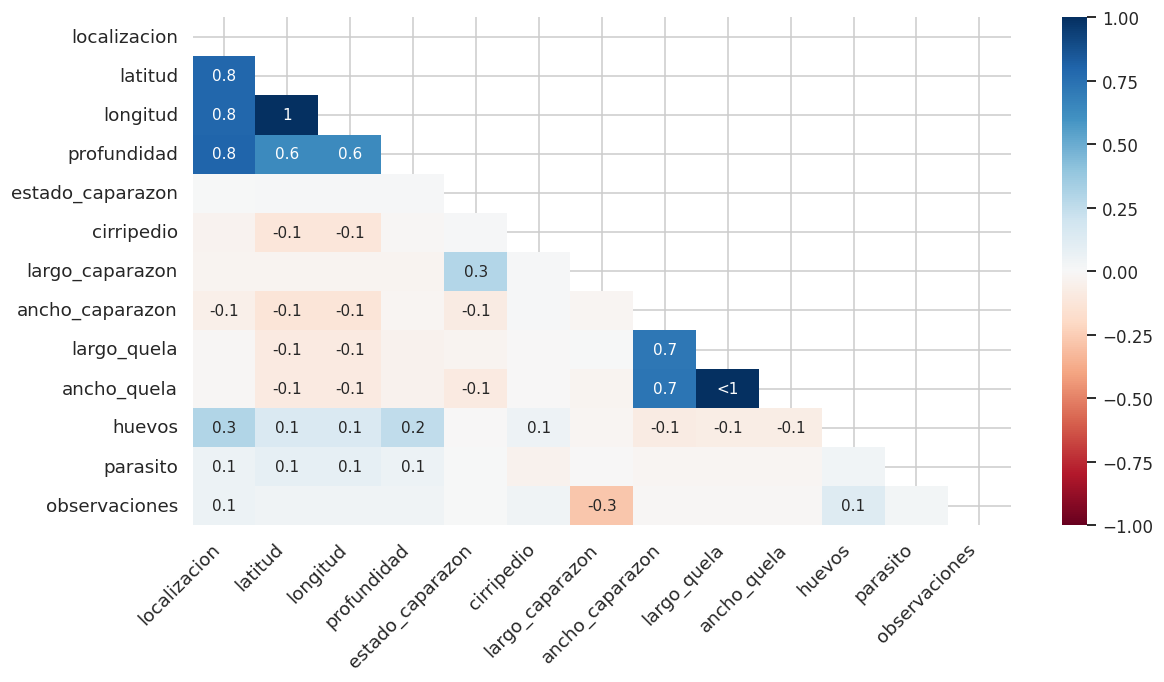

In [13]:
# Correlacion entre variables
msno.heatmap(cent_raw,figsize=(12, 6), fontsize=12)

### 2. Visualizaciones exploratorias

### 2.1 **Cuál es la distribución entre especies?**

Lo primero que haremos será estudiar la composición del dataset en función de las especies muestreadas. Recordemos la codificación de este feature en el dataset:
- `especie`: 1 = Lithodes santolla; 2 = Paralomis granulosa.

Utilizaremos un gráfico torta para facilitar la interpretación.

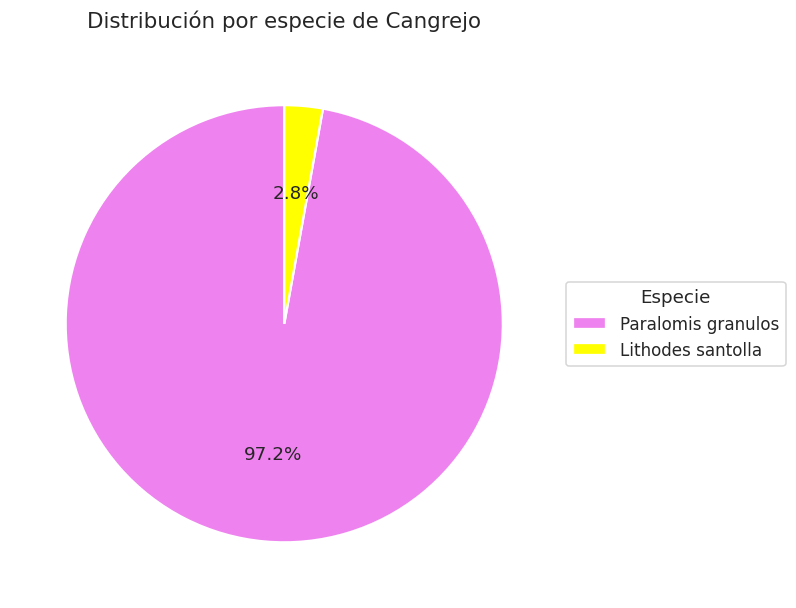

In [14]:
# Diccionario de mapeo (funciona si los datos son números o texto)
mapa_especies = {
    1: 'Lithodes santolla',
    2: 'Paralomis granulos',
    '1': 'Lithodes santolla',
    '2': 'Paralomis granulos',
}  # Cambia 'cat1' y 'cat2' por los nombres reales si lo deseas

# Conteo de valores
conteo = cent_raw['especie'].value_counts()

# Mapear los índices traducidos para la leyenda
etiquetas = [mapa_especies.get(x, str(x)) for x in conteo.index]

plt.figure(figsize=(7, 6))

# Generar el gráfico asignando los elementos a variables para la leyenda
wedges, texts, autotexts = plt.pie(
    conteo,
    autopct='%1.1f%%',
    colors=sns.color_palette(['violet', 'yellow']),
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
)

# Agregar la leyenda con las nuevas etiquetas
plt.legend(
    wedges,
    etiquetas,
    title='Especie',
    loc='center left',
    bbox_to_anchor=(1, 0, 0.5, 1),
)

plt.title('Distribución por especie de Cangrejo', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

_**Epígrafe:** Distribución de especies registradas durante las 6 campañas._

**Interpretación:** Se observa una enorme mayoría de centollas (*Lithodes santolla*) frente a un número reducido de centollones (*Paralomis granulos*), lo que refleja que es la especie objetivo de la pesquería en el canal Beagle. La relación 97.2 a 2.8 deja de manifiesto la necesidad de normalizar las distribuciones y nos sugiere implementar medidas de penalización desigual al entrenar modelos que utilicen este feature como variable predictiva.

### 2.2 En cada especie, **cuál es la distribución entre hembras y machos?**

Habiendo distinguido entre especies, queremos saber qué porcentaje corresponde a individuos machos y qué porcentaje a hembras. Se utiliza un gráfico de barras para responder a esto.

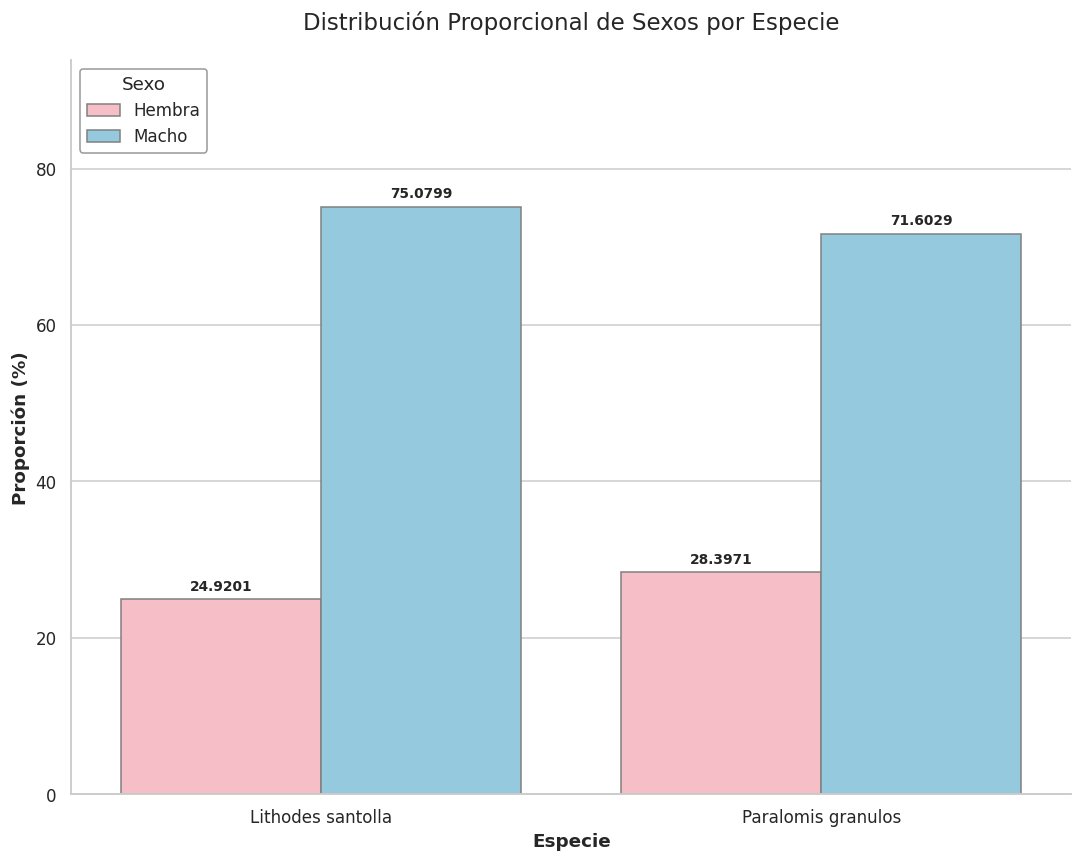

In [15]:
# 1. Mapeos de codificación
mapa_sexo = {
    1: 'Macho',
    2: 'Hembra'
}

# 2. Aplicar mapeo a una copia del DataFrame
df_plot = cent_raw.copy()
df_plot['especie_nom'] = df_plot['especie'].map(mapa_especies)
df_plot['sexo_nom'] = df_plot['sexo'].map(mapa_sexo)

# 3. Calcular Conteos (N) y Porcentajes dentro de cada especie
ct_counts = pd.crosstab(df_plot['especie_nom'], df_plot['sexo_nom'])
ct_pct = (
    pd.crosstab(
        df_plot['especie_nom'], df_plot['sexo_nom'], normalize='index'
    )
    * 100
)

# Convertir a formato largo para Seaborn
df_counts = ct_counts.reset_index().melt(
    id_vars='especie_nom', value_name='n_muestras'
)
df_pct = ct_pct.reset_index().melt(
    id_vars='especie_nom', value_name='porcentaje'
)
df_final = pd.merge(df_counts, df_pct, on=['especie_nom', 'sexo_nom'])

# Paleta exacta: Celeste para Macho, Rosa para Hembra
paleta_sexo = {'Macho': '#87CEEB', 'Hembra': '#FFB6C1'}  # Skyblue y Lightpink

# 4. Crear el gráfico
plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=df_final,
    x='especie_nom',
    y='porcentaje',
    hue='sexo_nom',
    palette=paleta_sexo,
    edgecolor='gray',
    linewidth=1,
)

# 5. Agregar el número de muestras (N) sobre cada barra
for container in ax.containers:
    # Identificar a qué sexo pertenece el contenedor actual
    sexo_cat = container.get_label()
    sub_df = df_final[df_final['sexo_nom'] == sexo_cat]

    # Crear etiquetas con N real y %
    etiquetas = [
        f"N={row['n_muestras']}\n({row['porcentaje']:.1f}%)"
        for _, row in sub_df.iterrows()
    ]

    # Colocar texto sobre las barras
    ax.bar_label(
        container, labels=etiquetas, padding=4, fontsize=9, fontweight='bold'
    )

# 6. Estética y Caja de Leyenda
plt.title('Distribución Proporcional de Sexos por Especie', fontsize=15, pad=20)
plt.xlabel('Especie', fontweight='bold')
plt.ylabel('Proporción (%)', fontweight='bold')
plt.ylim(
    0, df_final['porcentaje'].max() * 1.25
)  # Margen superior para los textos

# Caja de leyenda
plt.legend(
    title='Sexo',
    loc='upper left',
    frameon=True,
    facecolor='white',
    edgecolor='gray',
)

sns.despine()
plt.tight_layout()
plt.show()

_**Epígrafe:** Proporción entre machos y hembras en ambas especies._

**Interpretación:** Vemos que en ambas especies la relación entre la cantidad de machos y hembras es cercana a 3:1. Recordemos que hablamos de proporciones y no de frecuencia, el 75% de centollas representa una cantidad de individuos mucho mayor al 75% de centollones. Esta proporción es coherente con una política pesquera que busca proteger a las hembras (vedas o liberación obligatoria) y con el hecho de que los machos alcanzan mayor talla comercial..

### 2.3 En cada especie, **hay diferencias significativas del largo del caparazón entre machos y hembras?**

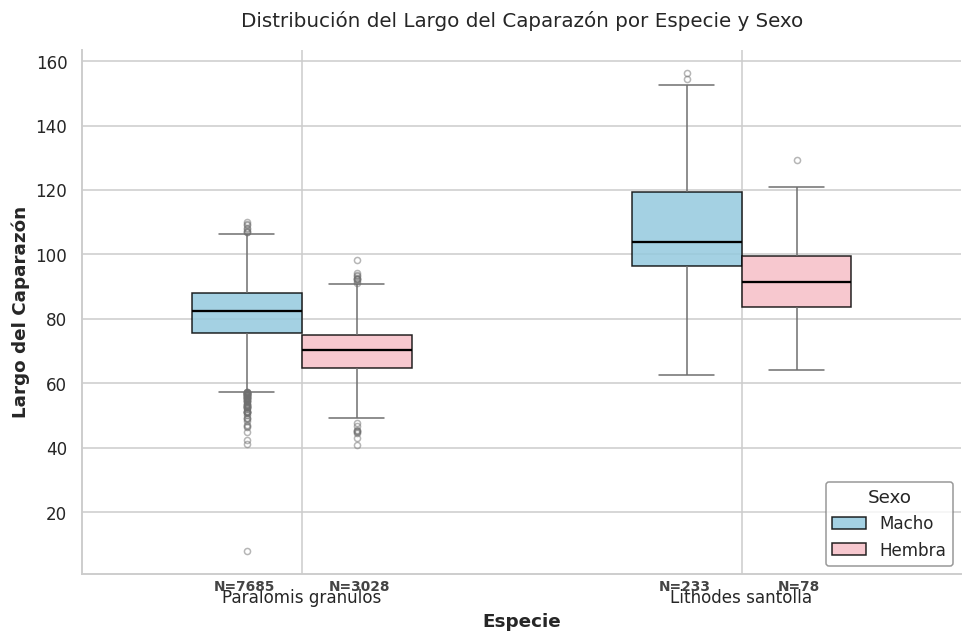

In [16]:
# 2. Preparar el DataFrame
df_plot = cent_raw.copy()
df_plot['especie_nom'] = df_plot['especie'].map(mapa_especies)
df_plot['sexo_nom'] = df_plot['sexo'].map(mapa_sexo)

# Columna del largo (ajusta el nombre exacto de tu columna si difiere)
col_largo = 'largo_caparazon'

# 3. Paleta de colores
paleta_sexo = {'Macho': '#87CEEB', 'Hembra': '#FFB6C1'}  # Celeste y Rosa

# 4. Crear la figura
plt.figure(figsize=(9, 6))

ax = sns.boxplot(
    data=df_plot,
    x='especie_nom',
    y=col_largo,
    hue='sexo_nom',
    palette=paleta_sexo,
    width=0.5,
    boxprops=dict(alpha=0.85, edgecolor='black', linewidth=1),
    medianprops=dict(color='black', linewidth=1.5),
    flierprops=dict(
        marker='o', markersize=4, alpha=0.5
    ),  # Muestra outliers
)

# 5. Agregar el tamaño muestral (N) debajo de cada caja
conteo_n = (
    df_plot.groupby(['especie_nom', 'sexo_nom'])[col_largo]
    .count()
    .unstack(fill_value=0)
)
especies_unicas = df_plot['especie_nom'].dropna().unique()

y_min = df_plot[col_largo].min()
y_range = df_plot[col_largo].max() - y_min
pos_y_text = y_min - (y_range * 0.06)  # Posición del texto N debajo del eje Y

for i, esp in enumerate(especies_unicas):
    for j, sexo in enumerate(['Macho', 'Hembra']):
        if esp in conteo_n.index and sexo in conteo_n.columns:
            n_val = conteo_n.loc[esp, sexo]
            # Offset x para alinear con la caja izquierda (Macho) o derecha (Hembra)
            offset_x = -0.13 if j == 0 else 0.13
            ax.text(
                i + offset_x,
                pos_y_text,
                f'N={n_val}',
                ha='center',
                va='top',
                fontsize=9,
                fontweight='bold',
                color='#444444',
            )

# 6. Estética y Caja de Leyenda
plt.title(
    'Distribución del Largo del Caparazón por Especie y Sexo',
    fontsize=13,
    pad=15,
)
plt.xlabel('Especie', fontweight='bold')
plt.ylabel('Largo del Caparazón', fontweight='bold')
plt.grid(True)

# Caja con leyenda para los colores
plt.legend(
    title='Sexo',
    loc='lower right',
    frameon=True,
    facecolor='white',
    edgecolor='gray',
)

sns.despine()
plt.tight_layout()
plt.show()

**Epígrafe:** Diagrama de caja del largo de caparazón (mm) para cada combinación de especie y sexo.

**Interpretación:** Dentro de cada especie, los machos presentan caparazones más largos que las
hembras, lo que es esperable biológicamente (dimorfismo sexual) y explica por qué son el objetivo
comercial. Al comparar especies, se observa una diferencia de tamaño entre centolla y centollón que
debería cuantificarse formalmente en el TP2 (p.ej. con un test de hipótesis), dado el N mucho menor
disponible para el centollón.

### 2.4 **Cómo varía la pesca en función de la profundidad?**

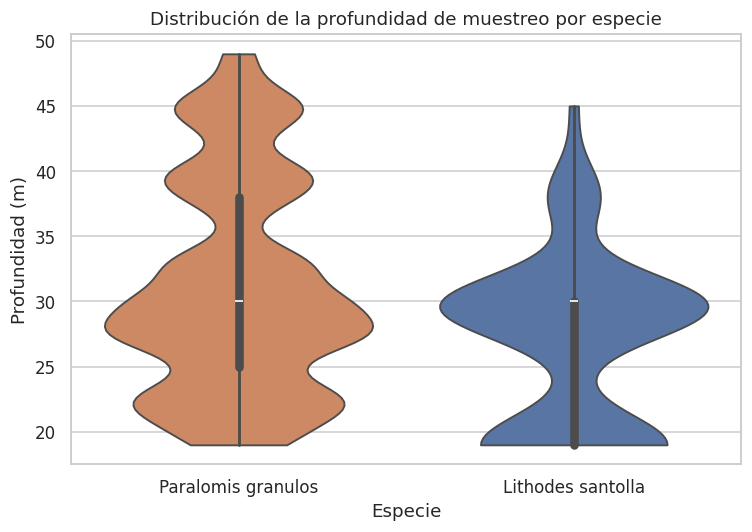

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
df_plot = cent_raw.copy()
df_plot['especie_nom'] = df_plot['especie'].map(mapa_especies)
sns.violinplot(data=df_plot, x="especie_nom", y="profundidad", hue="especie",
               palette=["#4c72b0", "#dd8452"], legend=False, ax=ax, cut=0)
ax.set_xlabel("Especie")
ax.set_ylabel("Profundidad (m)")
ax.set_title("Distribución de la profundidad de muestreo por especie")
plt.tight_layout()
plt.show()

_**Epígrafe:** Distribución (violin plot) de la profundidad (m) de los puntos de muestreo en que se registró cada especie._

**Interpretación:** Ambas especies se distribuyen en un rango de profundidad similar (~19–49 m), sin una separación clara. Esto sugiere que, al menos en el rango muestreado, no hay una segregación batimétrica marcada entre especies, aunque el n reducido de centollón limita la solidez de esta lectura. La mayor presencia de ambas especies se encuentra cerca de los 28 m.

### 2.5 **Qué frecuencia de presencia de parásitos hay?**

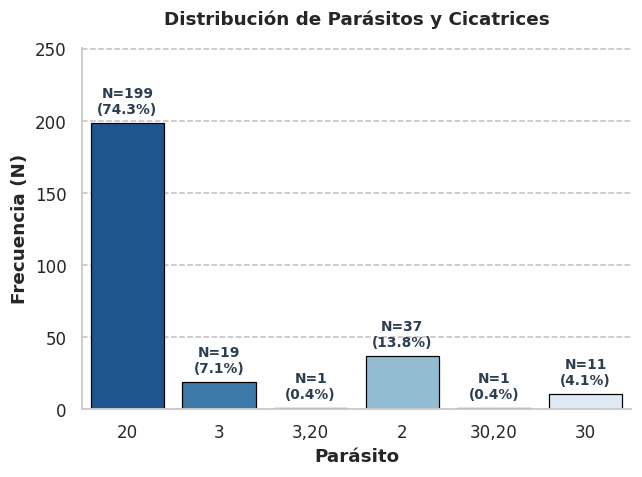

In [18]:
plt.figure(figsize=(6, 4.5))

# 1. Gráfico de conteo directo con la columna str original
ax = sns.countplot(
    data=cent_raw,
    x='parasito',
    hue='parasito',
    palette='Blues_r',
    legend=False,
    edgecolor='black',
    linewidth=0.8,
)

# 2. Total de registros no nulos para calcular el porcentaje
total = cent_raw['parasito'].notna().sum()

# 3. Anotar N y % sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = 100 * height / total
        ax.annotate(
            f'N={int(height)}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            color='#2c3e50',
        )

# 4. Ajuste dinámico del margen superior para evitar corte de texto
plt.ylim(0, ax.get_ylim()[1] * 1.20)

# Estética
plt.title(
    'Distribución de Parásitos y Cicatrices',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Parásito', fontweight='bold')
plt.ylabel('Frecuencia (N)', fontweight='bold')

sns.despine(top=True, right=True)
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

_**Epígrafe:** Presencia de parásitos sobre el total de registros._

**Interpretación:** A partir del gráfico, se observa que sólo el 21.3% de los casos que presentan señales de parásitos corresponden a parásitos presentes, mientras que el 78.7% restante muestra cicatrices de parásitos anteriores. A su vez, vemos que es más frecuente ver señales de isópodos (88,1%) que de rizocefalos (11.9%).

### 2.6 **Qué cirripedios son más comunes de ver? (tamaño y ubicación)**

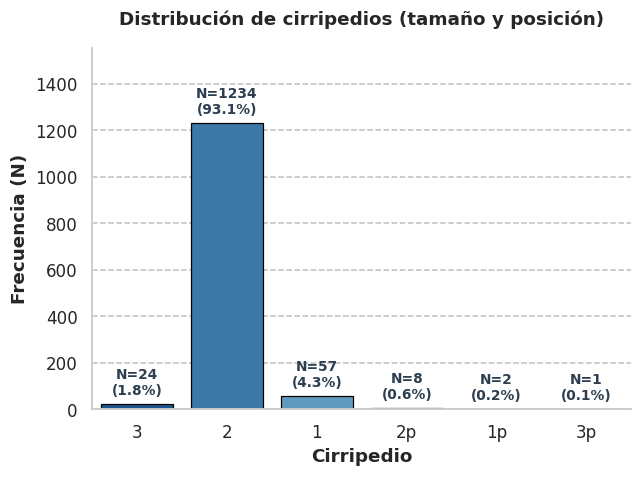

In [19]:
plt.figure(figsize=(6, 4.5))

# 1. Gráfico de conteo directo con la columna str original
ax = sns.countplot(
    data=cent_raw,
    x='cirripedio',
    hue='cirripedio',
    palette='Blues_r',
    legend=False,
    edgecolor='black',
    linewidth=0.8,
)

# 2. Total de registros no nulos para calcular el porcentaje
total = cent_raw['cirripedio'].notna().sum()

# 3. Anotar N y % sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = 100 * height / total
        ax.annotate(
            f'N={int(height)}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            color='#2c3e50',
        )

# 4. Ajuste dinámico del margen superior para evitar corte de texto
plt.ylim(0, ax.get_ylim()[1] * 1.20)

# Estética
plt.title(
    'Distribución de cirripedios (tamaño y posición)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Cirripedio', fontweight='bold')
plt.ylabel('Frecuencia (N)', fontweight='bold')

sns.despine(top=True, right=True)
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

_**Epígrafe:** Presencia de cirripedios sobre el total de registros._

**Interpretación:** Vemos que los cirripedios más habituales se encuentran en el caparazón y tienen un tamaño medio. Este escenario representa el 93.1% de los casos registrados. Menos del 1% de cirripedios se encuentran en las patas.

### 2.7 **Usualmente, en qué estado se encuentra el caparazón del individuo?**

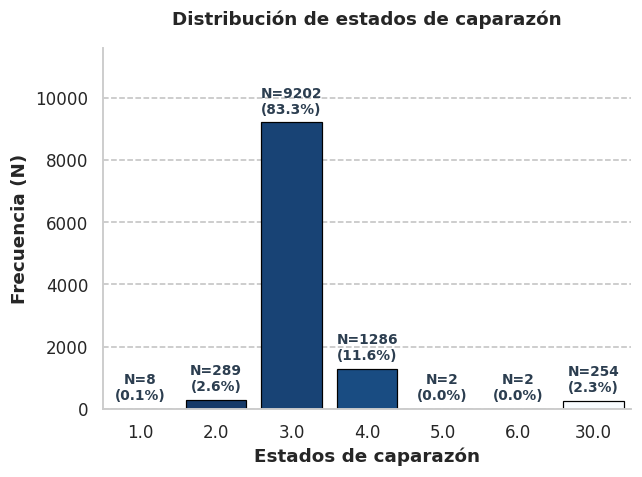

In [20]:
plt.figure(figsize=(6, 4.5))

# 1. Gráfico de conteo directo con la columna str original
ax = sns.countplot(
    data=cent_raw,
    x='estado_caparazon',
    hue='estado_caparazon',
    palette='Blues_r',
    legend=False,
    edgecolor='black',
    linewidth=0.8,
)

# 2. Total de registros no nulos para calcular el porcentaje
total = cent_raw['estado_caparazon'].notna().sum()

# 3. Anotar N y % sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = 100 * height / total
        ax.annotate(
            f'N={int(height)}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            color='#2c3e50',
        )

# 4. Ajuste dinámico del margen superior para evitar corte de texto
plt.ylim(0, ax.get_ylim()[1] * 1.20)

# Estética
plt.title(
    'Distribución de estados de caparazón',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Estados de caparazón', fontweight='bold')
plt.ylabel('Frecuencia (N)', fontweight='bold')

sns.despine(top=True, right=True)
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

_**Epígrafe:** Estudio del estado de caparazón sobre el total de registros._

**Interpretación:** Vemos que en el 94.9% de los casos registrados, los cangrejos tienen un caparazón duro con epibiontes. Solo 4 casos dan señales de cambio de caparazón y 8 son cangrejos en fase de postmuda.

### 2.8 **En qué temporada la pesca es mayor?**

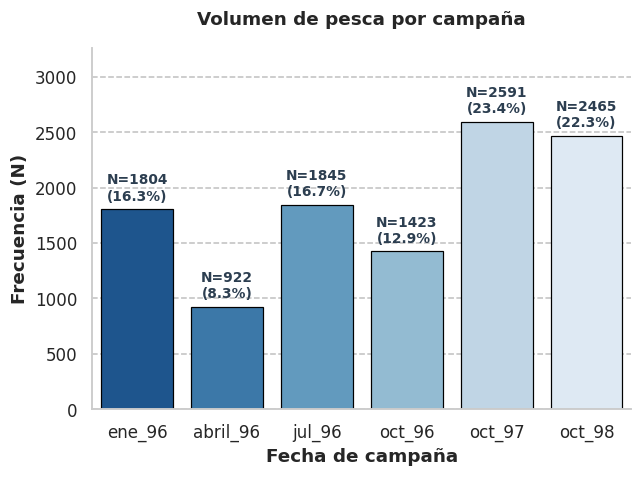

In [21]:
plt.figure(figsize=(6, 4.5))

# 1. Gráfico de conteo directo con la columna str original
ax = sns.countplot(
    data=cent_raw,
    x='fecha',
    hue='fecha',
    palette='Blues_r',
    legend=False,
    edgecolor='black',
    linewidth=0.8,
)

# 2. Total de registros no nulos para calcular el porcentaje
total = cent_raw['fecha'].notna().sum()

# 3. Anotar N y % sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = 100 * height / total
        ax.annotate(
            f'N={int(height)}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            color='#2c3e50',
        )

# 4. Ajuste dinámico del margen superior para evitar corte de texto
plt.ylim(0, ax.get_ylim()[1] * 1.20)

# Estética
plt.title(
    'Volumen de pesca por campaña',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Fecha de campaña', fontweight='bold')
plt.ylabel('Frecuencia (N)', fontweight='bold')

sns.despine(top=True, right=True)
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

_**Epígrafe:** Distribución temporal del volumen de pesca según la campaña._

**Interpretación:** Se observa un mayor volumen de pesca durante el mes de octubre en los últimos dos años registrados. La campaña de octubre del 96 tuvo menor éxito que las siguientes, posiblemente como consecuencia de la pesca abundante registrada en julio de ese año.
Abril del 96 tuvo el desempeño más bajo de todos los registros.

### Estudio del feature huevos

In [22]:
cent_raw['huevos'].unique()

array([nan, '1', '3', '0', '4', '5', '30', '6', '7', '7 en 1', 'conojos',
       'po', '7, 5 huevos', '7, pocos en 1', '7, 4 huevos degenerados',
       '7 clutch incompleto', '7 en 1, clutch incomp', '7, pocos <20',
       '40'], dtype=object)

In [23]:
cent_raw['huevos'].value_counts()

,count
huevos,
1,1232
0,825
30,458
5,209
6,98
7,92
3,82
4,36
40,10


### 3. Preguntas que podrían potencialmente ser respondidas

1. Cuál fue la evolución temporal en la pesca de cada especie?
2. Cuándo se encontraron más huevos en las hembras?
3. Dónde se pescaron mayor cantidad de hembras con huevos en estos periodos?
4. Cuáles son los puntos de mayor cantidad de pesca?
5. Dónde y cuándo se recomienda no pescar?